In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mpl
import seaborn as sb

In [3]:
pd.set_option('display.max_rows',500)

In [4]:
df_ecom=pd.read_csv(r"C:\Users\Admin\Ecom_DataCleaning.csv")

In [5]:
df_ecomcpy=df_ecom.copy()

In [6]:
df_ecomcpy.head(12)

,Unnamed: 0,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Revenue
0,0,100,Customer_100,ORD-41285,2024-11-22,Blender,Electronics,3,38.00,Cash on Delivery,Shipped,114.00
1,1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,538.35,PayPal,Processing,1076.70
2,2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,PayPal,Processing,1169.60
4,4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51
5,5,105,Customer_105,ORD-22442,2024-11-20,Tennis Racket,Sports,3,122.06,Cash on Delivery,Cancelled,366.18
6,6,106,Customer_106,ORD-25885,2025-02-02,Blender,Electronics,5,978.63,Bank Transfer,Processing,4893.15
7,7,107,Customer_107,ORD-89122,2025-01-03,Biography,Books,5,587.68,PayPal,Returned,2938.40
8,8,108,Customer_108,ORD-64400,2025-10-23,Science,Books,1,600.29,Cash on Delivery,Processing,600.29
9,9,109,Customer_109,ORD-18512,2025-05-03,Tennis Racket,Sports,5,168.34,Credit Card,Shipped,841.70


In [7]:
print(mpl.style.available,end=' ')

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10'] 

# **Revenue Drivers**

## 1. Revenue by catagory

In [238]:
# finding total revenue generated for each ecomm product catagory
Rvb_cat=df_ecomcpy.groupby('Category').agg({'Revenue':'sum'})
Rvb_cat

,Revenue
Category,
Books,42765.06
Clothing,35139.81
Electronics,60156.14
Home,14306.44
Sports,30590.09


### *Piechart presentation*

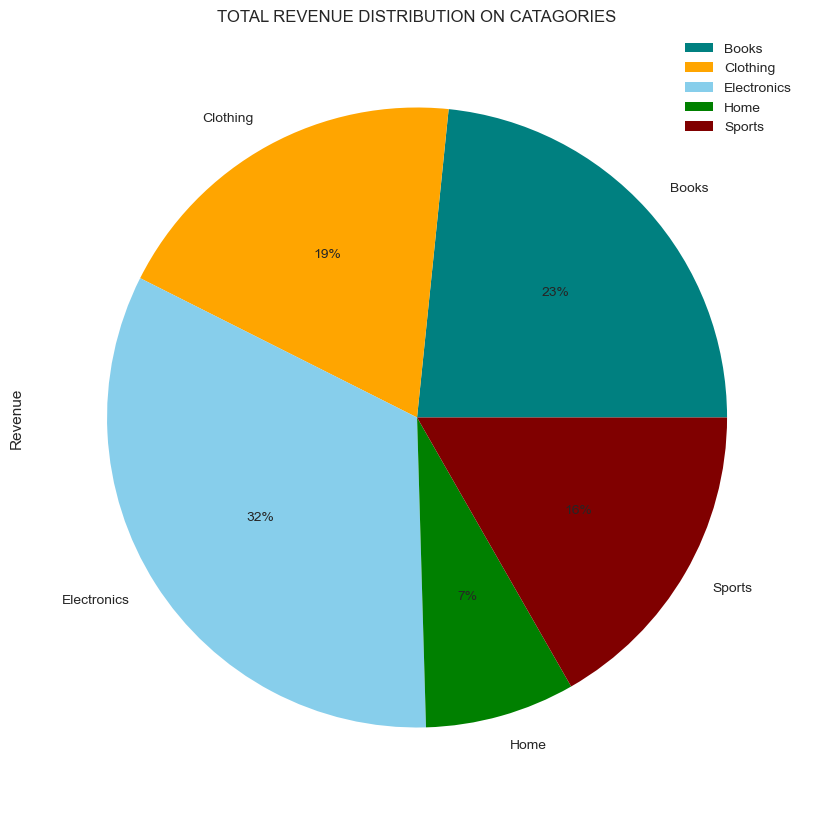

In [239]:
#Data visualization of revenue by each catagory through a pie chart
Rvb_cat.plot(kind='pie',y='Revenue',figsize=(10,12),autopct='%i%%',colors=['teal','orange','skyblue', 'green','maroon','#B22222'])
mpl.title('Total Revenue distribution on Catagories'.upper())
mpl.show()

* Electronics items takes up the most share in total revenue with 32% of the total share.
* Home contributes with the least which is only 7% of the total revenue.
* The categories of Sports, Clothing and Books are relatively even in terms of revenue distribution.

### *Using barplot(Seaborn) to visualize*

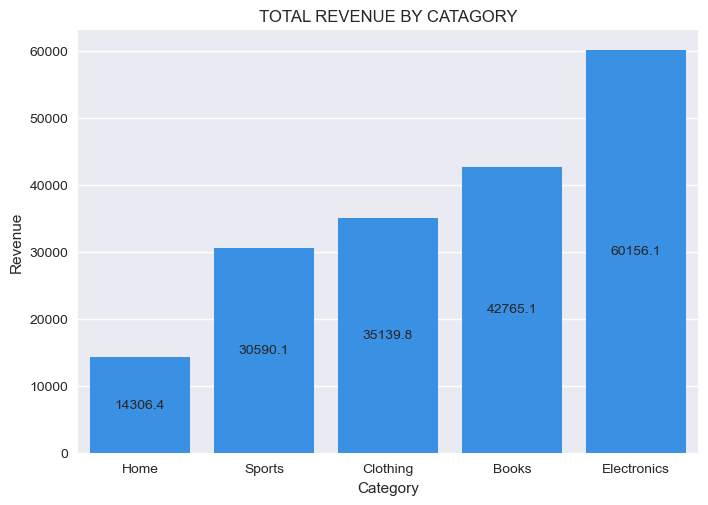

In [240]:
# visualizing the total revenue generated by each catagory using a barplot
Rvb_cat.sort_values('Revenue',inplace=True)
bpv=sb.barplot(data=Rvb_cat,y='Revenue',x=Rvb_cat.index,color='#1E90FF')
bpv.bar_label(bpv.containers[0],label_type ='center')

mpl.title('Total Revenue by Catagory'.upper())
mpl.show()

## 2. Top Performing Products

In [241]:
#Finding out top 10 best performing product based on the revenue data
tp_pd=df_ecomcpy.groupby('Product').agg({'Revenue':'sum'}).sort_values('Revenue',ascending=False).head(10)
tp_pd

,Revenue
Product,
Blender,32968.53
Shoes,17420.42
Comics,17420.39
Lamp,14306.44
Basketball,11499.17
Biography,9577.39
T-Shirt,8230.26
Science,8005.71
Fiction,7761.57


### *Using Horizontal Bar plot*

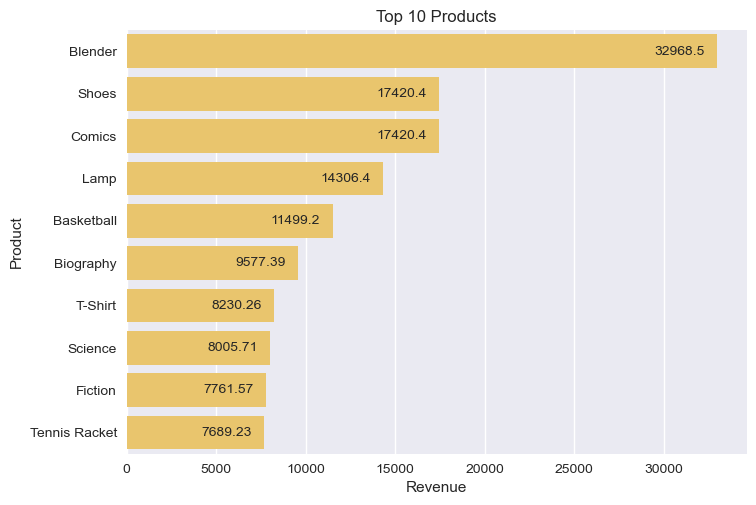

In [242]:

bhp=sb.barplot(data=tp_pd,
           x='Revenue',
           y=tp_pd.index,
           color='#fece58'
          )
bhp.bar_label(bhp.containers[0],label_type='edge',padding=-45)
mpl.title("Top 10 Products")
mpl.show()

* Blender has the most revenue share overall with a value above 30K and with a huge margin from the remaining products.
* Shoes and Comics are the next best‑performing products, generating almost half the value of Blenders.
* Among the top 10 performers, the lower 5 show evenly matched Revenue contributions.

## 3. Revenue Trend Over Time

In [17]:
#converting order_date values into datetime dtype to extract month and days separately
df_ecomcpy=df_ecomcpy.astype({'Order_Date':'datetime64[ns]'})

In [251]:
#crosschecking the data types of the order_date column
df_ecomcpy.dtypes

Unnamed: 0                 int64
ID                         int64
Customer_Name             object
Order_ID                  object
Order_Date        datetime64[ns]
Product                   object
Category                  object
Quantity                   int64
Price                    float64
Payment_Method            object
Status                    object
Revenue                  float64
dtype: object

In [252]:
#fetching months in short wording format using .dt.strftime() method
df_ecomcpy['Month']=df_ecomcpy['Order_Date'].dt.strftime('%b')     #to get the month in words
print(df_ecomcpy['Month'].values)
# df_ecomcpy['Order_Date'].dt.day_name()         #to get the day in words

['Nov' 'Jul' 'Dec' 'Mar' 'Oct' 'Nov' 'Feb' 'Jan' 'Oct' 'May' 'Sep' 'Oct'
 'Mar' 'Jul' 'Jan' 'Jan' 'Oct' 'Feb' 'May' 'Dec' 'Jun' 'Oct' 'May' 'Oct'
 'May' 'Feb' 'May' 'May' 'Nov' 'Jun' 'Aug' 'Jun' 'Apr' 'Dec' 'Oct' 'Feb'
 'Jun' 'Feb' 'Aug' 'Feb' 'Feb' 'Feb' 'Oct' 'Jul' 'Jan' 'May' 'Jul' 'May'
 'Mar' 'Jun' 'Nov' 'Jul' 'Sep' 'Jul' 'Feb' 'May' 'Nov' 'Nov' 'Apr' 'Jul'
 'Jan' 'Dec' 'May' 'Jan' 'Feb' 'Nov' 'Jul' 'Aug' 'Nov' 'Aug' 'Oct' 'Dec'
 'Nov' 'Oct' 'Sep' 'Feb' 'Jul' 'Jul' 'Sep' 'Sep' 'Mar' 'Dec' 'Aug' 'Mar'
 'Feb' 'Aug' 'Oct' 'Nov' 'Nov' 'Aug' 'Jun' 'Jul' 'Aug' 'Feb' 'Jun' 'Dec'
 'Jun' 'Jul' 'Jan']


In [253]:
# to sort months in chronological we use pandas Categorical method make them as months instead of strings for sorting
#it remains default sorted but while using sort_values() it will be arragned as per the categorical() setting
df_ecomcpy['Month']=pd.Categorical(df_ecomcpy['Month'],
               categories=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
               ordered=False
              )

In [254]:
# Revenue trend on mothly basis
rev_tr=df_ecomcpy.groupby(['Month'],as_index=False,observed=True).agg({'Revenue':'sum'})
rev_tr.sort_values('Month',inplace=True)

In [255]:
rev_tr

,Month,Revenue
0,Jan,13383.47
1,Feb,47522.69
2,Mar,8367.61
3,Apr,1200.28
4,May,15372.76
5,Jun,17876.43
6,Jul,16169.50
7,Aug,10403.98
8,Sep,8163.43
9,Oct,20994.40


### *Using bar graph*

##### **Revenue Trend on each month**

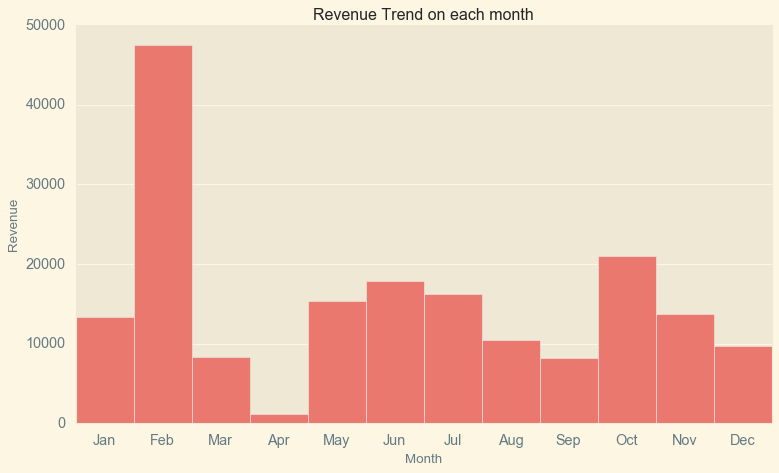

In [308]:
with mpl.style.context(mpl.style.available[0]):
    mpl.figure(figsize=(10,6))
    # mpl.grid(visible=True)
    sb.barplot(data=rev_tr,x='Month',y='Revenue',color='#ff665a',width=1)

mpl.title('Revenue Trend on each month')
mpl.show()

* Revenue peaked in February, making it the most productive month.
* Revenue performance remained steady from May through December, with only a slight dip in September.
* April remained the poorest performing month throughout the year. 

### *Using line graph*

##### **Revenue over the years**

In [18]:

df_ecomcpy['year']=df_ecomcpy['Order_Date'].dt.year

In [19]:
rv_yr=df_ecomcpy.groupby('year',as_index=False).agg({'Revenue':'sum'})
rv_yr

,year,Revenue
0,2023,3254.02
1,2024,22119.61
2,2025,157583.91


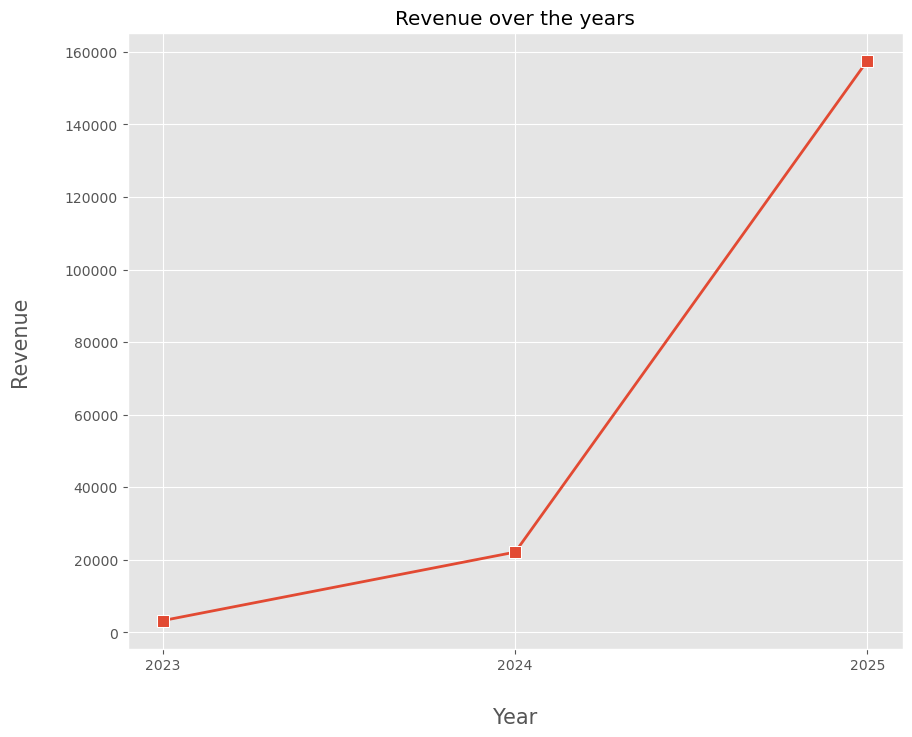

In [22]:
with mpl.style.context(mpl.style.available[9]):
    mpl.figure(figsize=(10,8))
    ax=sb.lineplot(data=rv_yr,x='year',y='Revenue',marker='s',linewidth=2,markersize=8)
    
    
    ax.set_xlabel('Year',fontsize=15,labelpad=25)
    ax.set_ylabel('Revenue',fontsize=15,labelpad=25)
    
    ax.set_xticks(ticks=[i for i in rv_yr['year']])
    ax.set_xticklabels([i for i in rv_yr['year']])
    
    mpl.title("Revenue over the years")
    mpl.show()

* The trend shows a steady increase, suggesting stable improvement year‑over‑year.
* A significant jump occurs between 2024 and 2025, indicating accelerated growth suggesting high demands and popularity.
* The sharp rise could be linked to expansion, new product launches, or market demand surges

##### **Revenue trend in the year 2024**

In [42]:
rpy=df_ecomcpy.loc[df_ecomcpy['Order_Date'].dt.year.isin([2024]),['Order_Date','Revenue']]
rpy['Order_Date']=pd.to_datetime(rpy['Order_Date'])
rpy.sort_values('Order_Date')

,Order_Date,Revenue
65,2024-11-08,886.26
28,2024-11-10,2696.07
72,2024-11-18,1885.52
87,2024-11-19,2648.88
88,2024-11-19,2520.25
5,2024-11-20,366.18
0,2024-11-22,114.00
50,2024-11-27,206.19
56,2024-11-28,1076.70
33,2024-12-05,1716.20


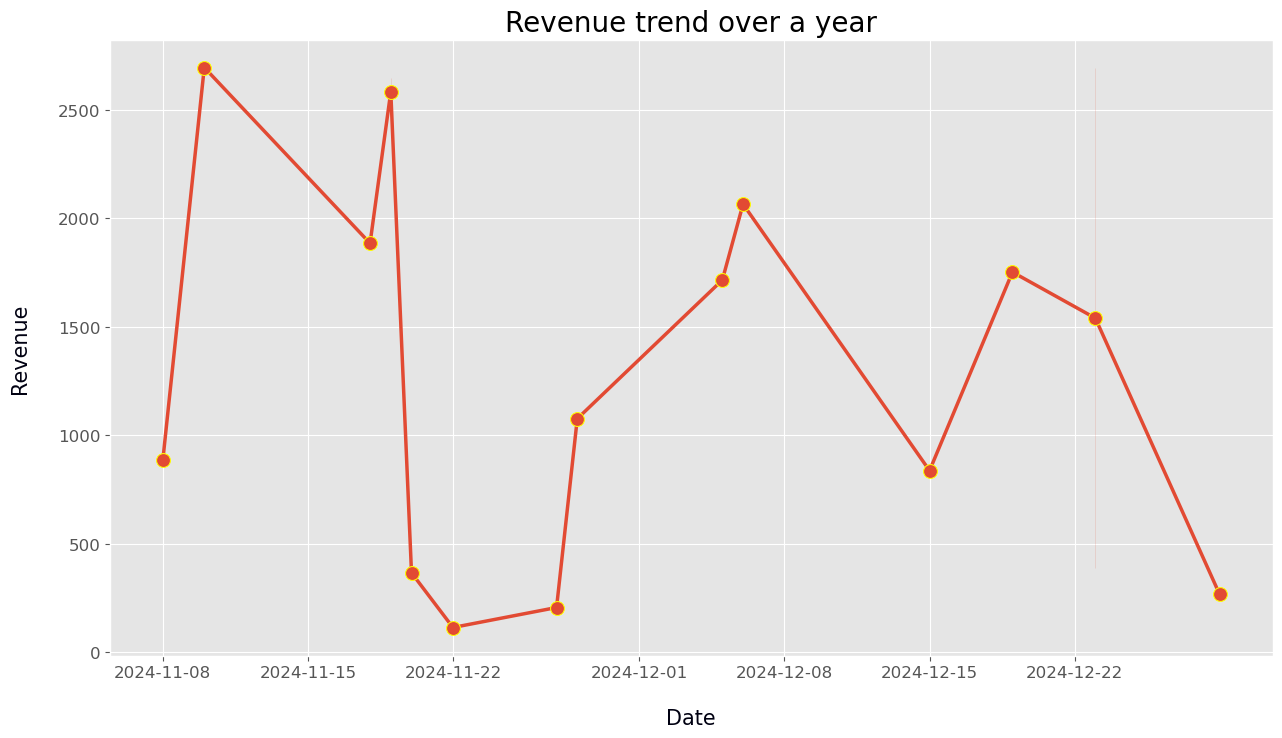

In [48]:
with mpl.style.context(mpl.style.available[9]):
    mpl.figure(figsize=(15,8))
    ax=sb.lineplot(data=rpy,x='Order_Date',y='Revenue',marker='o',markeredgecolor='yellow',markersize=10,linewidth=2.5)
    
    ax.set_xlabel('Date',fontsize=15,labelpad=20,color='#000011')
    ax.set_ylabel('Revenue',fontsize=15,labelpad=20,color='#000011')
    
    ax.tick_params(axis='both',labelsize=12,)

mpl.title("Revenue trend over a year",fontsize=20)
mpl.show()


* Volatility: Revenue shows noticeable fluctuations, with sharp peaks and dips rather than a smooth trend.

* High Points: Strong spikes appear around mid‑November and early December, suggesting seasonal demand or promotional impact.

* Low Points: Clear drops are visible in late November and again in late December, indicating possible post‑peak slowdowns.

* Pattern: The chart suggests a cyclical trend — bursts of high activity followed by short declines.

* Business Insight: Peaks may align with sales campaigns or festive periods, while dips could reflect fulfillment delays or reduced demand after promotions.

### *Using Pie chart*

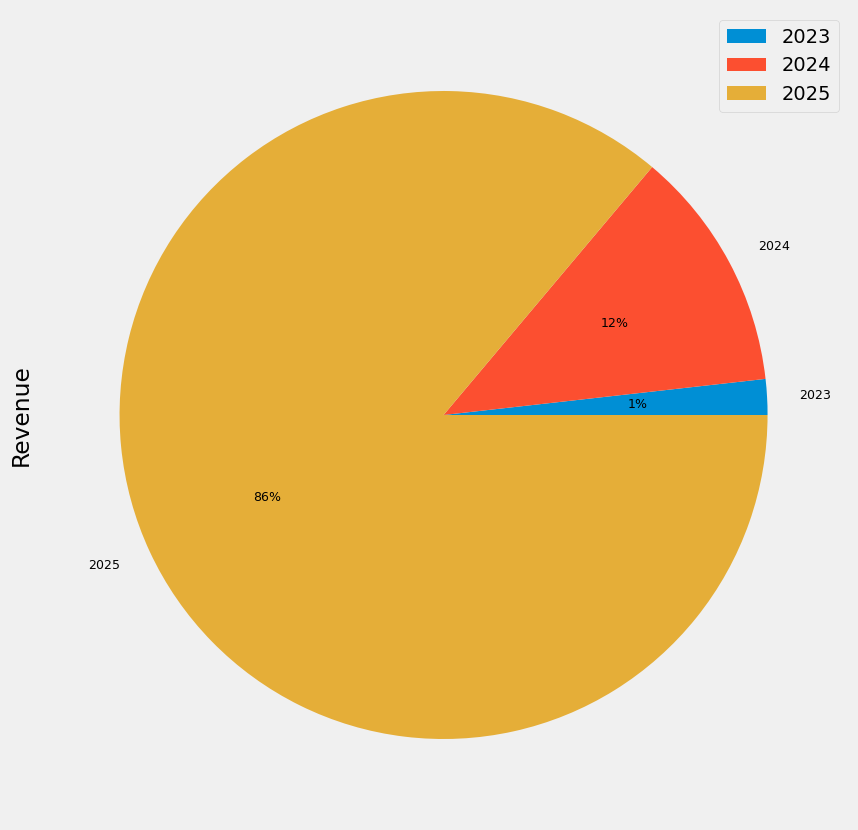

In [58]:
rv_yr.set_index('year').plot(kind='pie',y='Revenue',figsize=(12,10),autopct="%i%%",textprops={'fontsize':9})
mpl.show()

# **Operational Inefficiencies**

## 1. Order Status Distribution

In [119]:
stat_cnt=df_ecomcpy.groupby(['Status'],as_index=False).agg(status_count=('Product','count')).sort_values('status_count')
stat_cnt

,Status,status_count
1,Delivered,11
0,Cancelled,15
4,Shipped,21
2,Processing,25
3,Returned,27


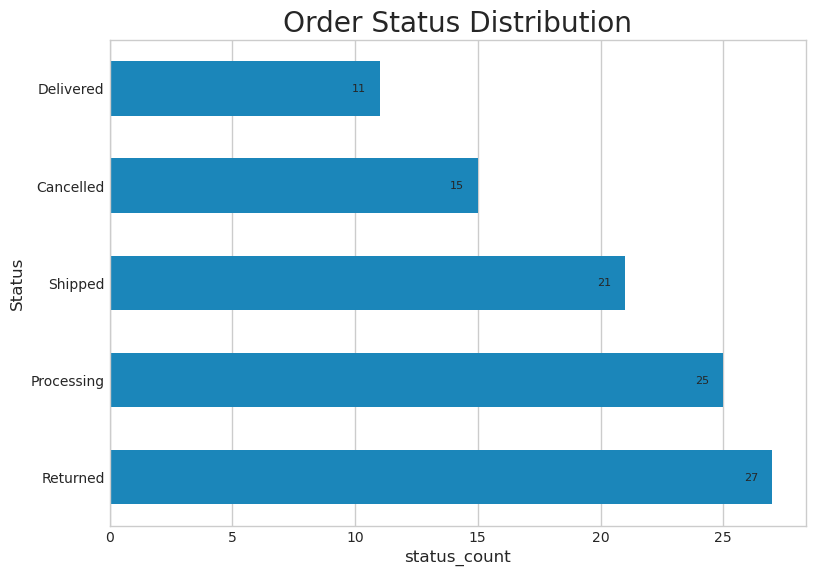

In [120]:
with mpl.style.context('seaborn-v0_8-whitegrid'):
    mpl.figure(figsize=(8,6))
    bpg=sb.barplot(data=stat_cnt,y='Status',x='status_count',gap =0.3)
    
    bpg.set_xlabel('status_count',fontsize=12)  # xlabel font size
    bpg.set_ylabel('Status',fontsize=12)        # ylabel font size
    bpg.tick_params(axis='x', labelsize=10)   # x-axis tick labels
    bpg.tick_params(axis='y', labelsize=10)   # y-axis tick labels
    
    bpg.bar_label(bpg.containers[0],label_type='edge',padding=-20,fontsize=8)
    mpl.title('Order Status Distribution')

*  Only 11 items have been successfully delivered within the expected timeframe — the smallest share.
*  A total of 27 items were returned, representing the largest negative impact.
*  25 items are still in the Processing stage, indicating pending fulfillment.

## 2. Category vs Status

In [310]:
rev_st=df_ecomcpy.groupby(['Status','Category']).agg({'Revenue':'sum'})
# rev_st.sort_values(['Revenue','Category'],inplace=True)
rev_st

Revenue
Status     Category             
Cancelled  Books         7456.63
           Clothing      7481.05
           Electronics   9370.09
           Sports        6019.77
Delivered  Clothing      3894.78
           Electronics   4053.80
           Home          2696.07
           Sports        5353.80
Processing Books         4887.63
           Clothing      9432.75
           Electronics  29991.74
           Home           531.06
           Sports       12570.90
Returned   Books        22151.96
           Clothing      3547.22
           Electronics   7181.88
           Home          6236.71
           Sports        5803.92
Shipped    Books         8268.84
           Clothing     10784.01
           Electronics   9558.63
           Home          4842.60
           Sports         841.70

### *Using grouped bar plot*

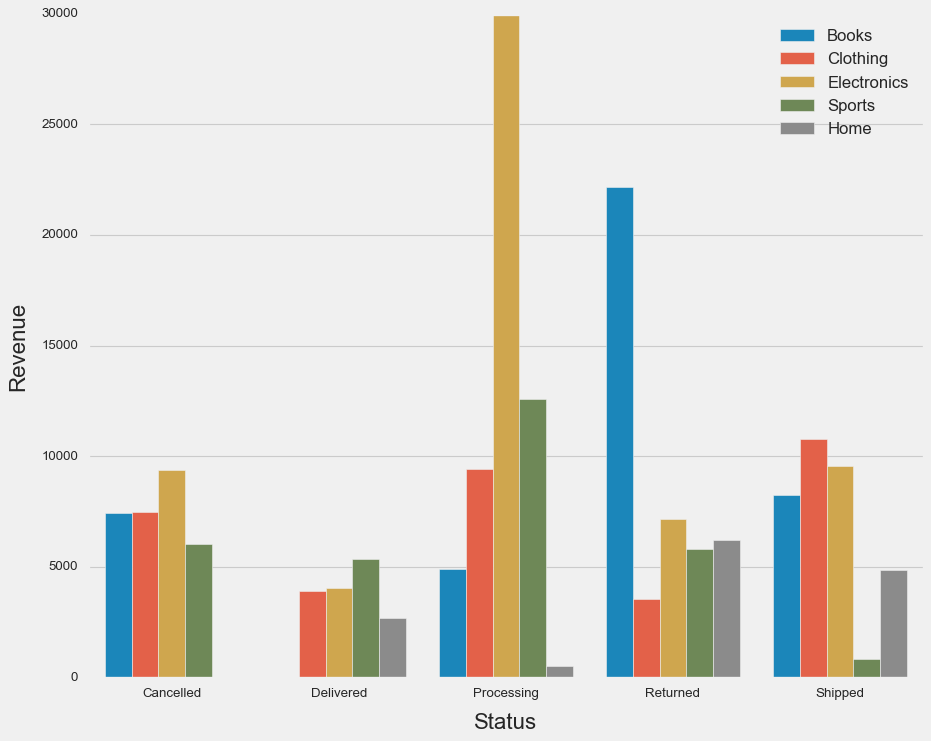

In [352]:
with mpl.style.context(mpl.style.available[8]):
    mpl.figure(figsize=(12,10))
    ax=sb.barplot(data=rev_st,x=[i for i,j in rev_st.index],y='Revenue',hue=[j for i,j in rev_st.index],legend='brief')
    ax.legend(fontsize=15)
    ax.set_xlabel('Status',fontsize=20,labelpad=12)
    ax.set_ylabel('Revenue',fontsize=20,labelpad=12)
    ax.tick_params(axis='both',labelsize=12)
mpl.show()

* Books are the most frequently returned category
* Electronics contributes the highest revenue but its the same category that has been cancelled the most.
* The most delivered items are from the sport category.

### *Using stacked bar plot*

In [354]:
rev_st=df_ecomcpy.groupby(['Status','Category'],as_index=False).agg({'Revenue':'sum'})
rev_stp=rev_st.pivot(index='Category',columns='Status',values='Revenue')
rev_stp.fillna(0,inplace=True)

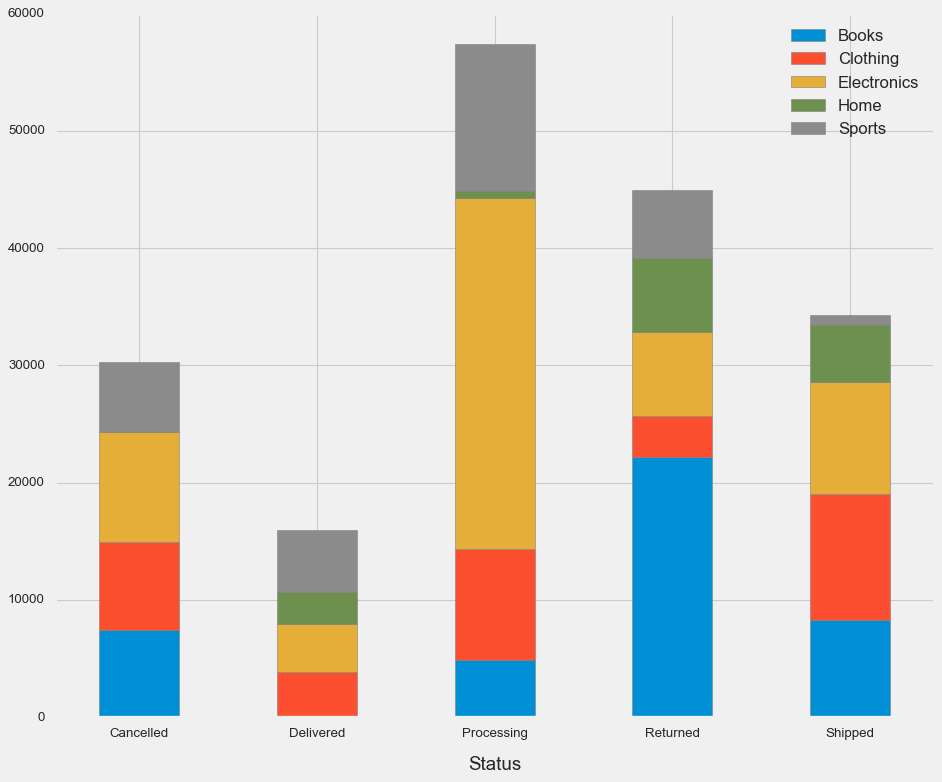

In [363]:
with mpl.style.context(mpl.style.available[8]):
    ax=rev_stp.T.plot(kind='bar',stacked=True,figsize=(12,10),fontsize=10,rot=0,width=0.45,edgecolor='grey')
    ax.legend(fontsize=15)
    ax.set_xlabel('Status', labelpad=15)
    ax.tick_params(axis='both',labelsize=12)
    # for i in range(5):
        # ax.bar_label(ax.containers[i],label_type='center',padding=5,fontsize=8.2)
mpl.tight_layout()
mpl.show()

* Electronics items dominates the processing state and also records the highest cancellations, signaling operational bottlenecks.
* Sports items stand out as the most delivered, yet they remain the least shipped, suggesting delivery efficiency but limited shipping volume.
* Books remains the most returned category, highlighting customer dissatisfaction or mismatched expectations.

## 3. Revenue by Order Status

### *Using single bar plot*

In [8]:
# Grouping the Status labels based on the sum of revenue
Rv_ord=df_ecomcpy.groupby('Status').agg({'Revenue':'sum'})
Rv_ord.sort_values('Revenue',inplace=True)
Rv_ord

,Revenue
Status,
Delivered,15998.45
Cancelled,30327.54
Shipped,34295.78
Returned,44921.69
Processing,57414.08


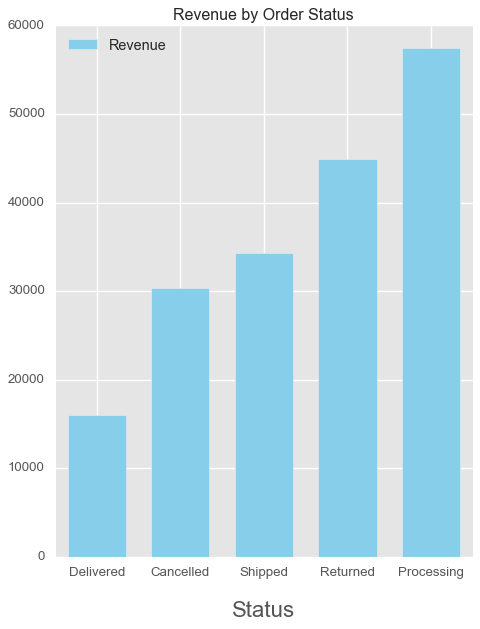

In [219]:
ax=Rv_ord.plot(kind='bar',color='#87ceea',figsize=(6,8),rot=0,xlabel='Status',fontsize=12,width=0.7)
ax.set_xlabel('Status',fontsize=20,labelpad=20)
# ax.set_ylabel('',fontsize=20,labelpad=20)
ax.set_xlim(-0.5, len(Rv_ord.index)-0.5) #to change the gaping between the bars
mpl.title("Revenue by Order Status")
mpl.show()

##### **calculating the revenue rate by status**

In [23]:

Rv_rt=df_ecomcpy.groupby(['Status'],as_index=False).agg({'Revenue':'sum'})
Rv_rt

,Status,Revenue
0,Cancelled,30327.54
1,Delivered,15998.45
2,Processing,57414.08
3,Returned,44921.69
4,Shipped,34295.78


In [24]:
#calculating revenue rate
Rv_rt['Rate']=Rv_rt['Revenue'].apply(lambda x:(x*100)/Rv_rt['Revenue'].sum())
Rv_rt.sort_values('Rate',inplace=True)

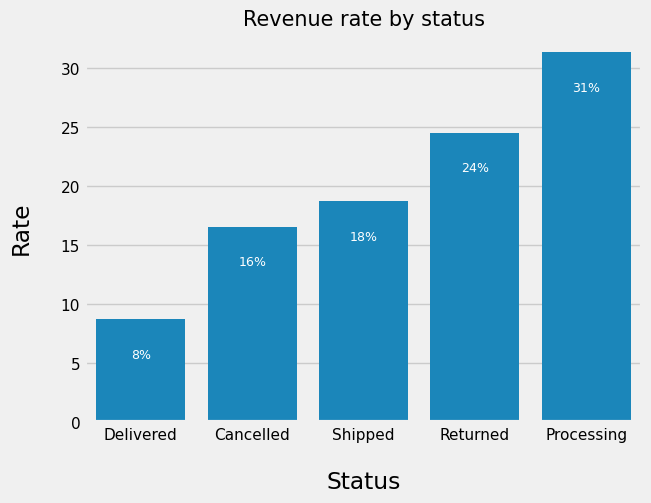

In [33]:
with mpl.style.context(mpl.style.available[8]):
    ax=sb.barplot(data=Rv_rt,x='Status',y='Rate')
   
    ax.set_xlabel('Status',labelpad=20)
    ax.set_ylabel('Rate',labelpad=20)
    ax.tick_params(axis='both',labelsize=11)
    ax.bar_label(ax.containers[0],label_type='edge',padding=-30,fontsize=9,color='white',fmt="%i%%")
    
    mpl.title("Revenue rate by status",fontsize=15)
    mpl.show()


* About 31% of total Revenue is currently in the Processing state — the largest share in the net distribution.
* Shipped and Cancelled items contribute at nearly the same rate, showing a balanced impact.
* Only 8% of items have been delivered so far, representing the lowest share of Revenue.

##### **Revenue Loss**

In [9]:
Rv_ord

,Revenue
Status,
Delivered,15998.45
Cancelled,30327.54
Shipped,34295.78
Returned,44921.69
Processing,57414.08


In [10]:
# Revenue loss = sum of revenue from Returned and cancelled
Rv_ord.loc[Rv_ord.index.isin(['Cancelled','Returned'])].agg('sum')

Revenue    75249.23
dtype: float64

In [14]:
# total revenue
Rv_ord.sum()

Revenue    182957.54
dtype: float64

In [17]:
100*(Rv_ord.query("(Status=='Cancelled')|(Status=='Returned')")['Revenue'].sum()/Rv_ord['Revenue'].sum())

np.float64(41.129340720256735)

In [50]:
l=float(Rv_ord.loc[['Cancelled','Returned'],'Revenue'].sum())
g=float(Rv_ord.loc[['Delivered'],'Revenue'].sum())
h=float(Rv_ord.loc[['Shipped','Processing'],'Revenue'].sum())

In [51]:
df_otc=pd.DataFrame({
    'Revenue':[g,l,h]},
    index=['Gain','Loss','In-progress']
                   )

In [52]:
df_otc

,Revenue
Gain,15998.45
Loss,75249.23
In-progress,91709.86


In [53]:
df_otc['Rate']=df_otc['Revenue'].apply(lambda x:(x*100)/df_otc['Revenue'].sum())
df_otc

,Revenue,Rate
Gain,15998.45,8.744351
Loss,75249.23,41.129341
In-progress,91709.86,50.126308


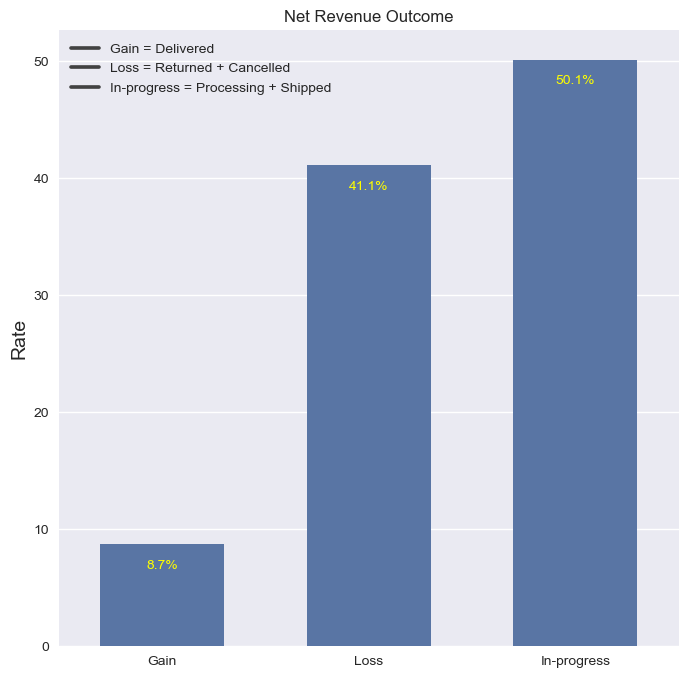

In [79]:
with mpl.style.context(mpl.style.available[12]):
    mpl.figure(figsize=(8,8))
    ax=sb.barplot(data=df_otc,x=df_otc.index,y='Rate',width=0.6)
    ax.legend( ["Gain = Delivered",
                    "Loss = Returned + Cancelled",
                    "In-progress = Processing + Shipped"],
          )
    ax.set_xlabel('')
    ax.set_ylabel('Rate',fontsize=14)
    ax.tick_params(axis='both',color='black')
    ax.bar_label(ax.containers[0],padding=-20,fmt="%.1f%%",color='yellow')
    mpl.title("Net Revenue Outcome")
    mpl.show()

* Net Revenue shows a modest 8.7% increase, driven entirely by delivered items.
* Nearly 50% of potential revenue remains on hold due to long processing times and slower shipping speeds.
* About 41% of revenue was lost because of heavy cancellations and a high volume of returned items.

# **Payment Method statistics**

## 1. Payment Method vs Status

### *Using grouped bar plot*

In [83]:
# grouping based on payment modes along with the catagory
df_ecomcpy.groupby(['Payment_Method','Category']).agg(count=('Category','count'))

count
Payment_Method   Category          
Bank Transfer    Books            4
                 Clothing         7
                 Electronics      7
                 Home             1
                 Sports           3
Cash on Delivery Books            8
                 Clothing         3
                 Electronics     13
                 Home             2
                 Sports           7
Credit Card      Books            4
                 Clothing         3
                 Electronics      7
                 Home             1
                 Sports           6
PayPal           Books            7
                 Clothing         4
                 Electronics      5
                 Home             3
                 Sports           4

In [88]:
# using pivot method to simplify the table in order to visualize it
df_pym=df_ecomcpy.groupby(['Payment_Method',
                            'Category'],
                             as_index=False).agg(count=('Category',
                                                        'count')).pivot(index='Category',
                                                                        columns='Payment_Method',
                                                                        values='count')
df_pym

Payment_Method,Bank Transfer,Cash on Delivery,Credit Card,PayPal
Category,,,,
Books,4,8,4,7
Clothing,7,3,3,4
Electronics,7,13,7,5
Home,1,2,1,3
Sports,3,7,6,4


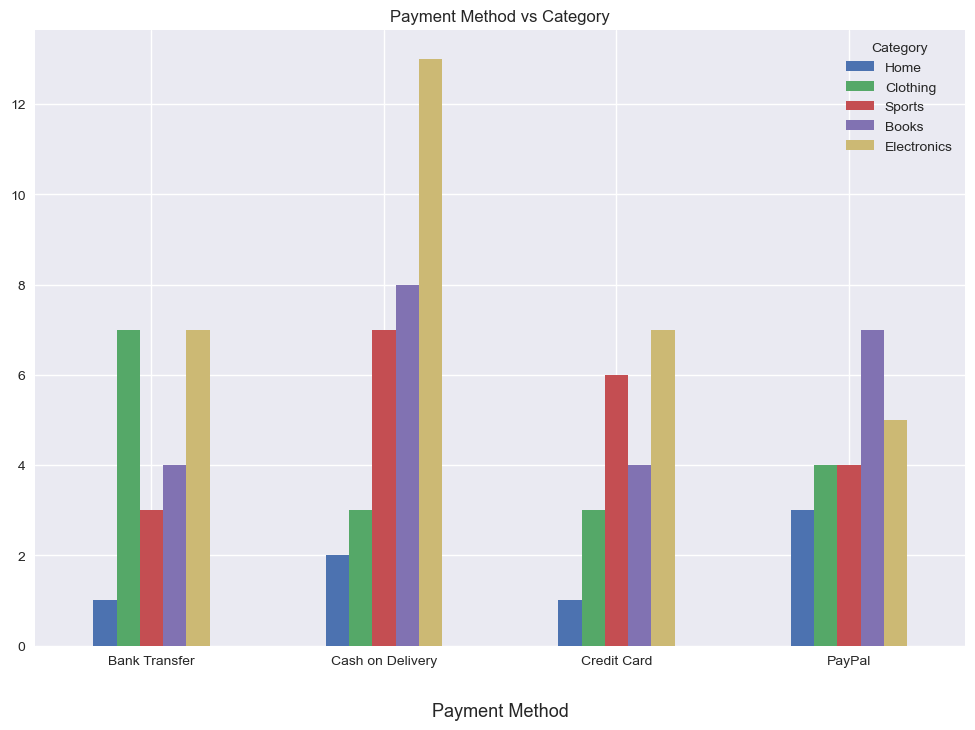

In [107]:
with mpl.style.context(mpl.style.available[12]):
    ax=df_pym.sort_values(['Cash on Delivery','Bank Transfer'],axis=0).T.plot(kind='bar',rot=0,figsize=(12,8))
    ax.set_xlabel('Payment Method',fontsize=13,labelpad=25)
    mpl.title("Payment Method vs Category")
    mpl.show()

* Cash on delivery is the most preferred method of payment overall, where Electronics were the highest among the items purchased via this method followed by books and sports.
* Home was the least purchased category overall via credit card and bank transfer.
* The majority of bank transfer purchases are for Clothing and Electronics.  

# **Finding Outliers**

### *Using Boxplot* 

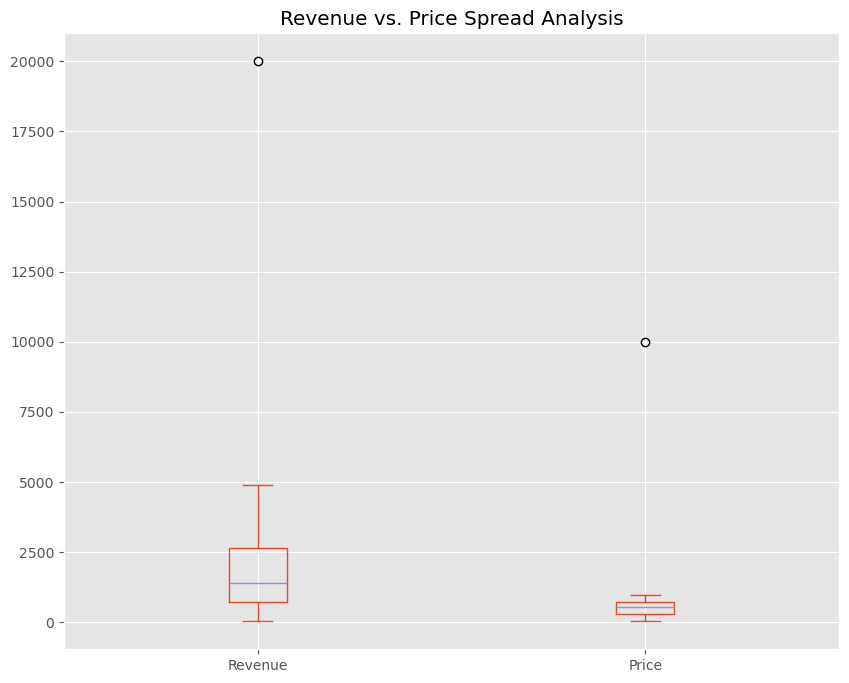

In [137]:
# using boxplot, we visualize the dataframe and finding out outliers

with mpl.style.context(mpl.style.available[9]):
    df_ecomcpy[['Revenue','Price']].sort_values(['Revenue','Price']).plot(kind='box',figsize=(10,8))
    mpl.title("Revenue vs. Price Spread Analysis")
    mpl.show()

* The isolated circular points at the top most part of the graph represents the outlier values.
* Revenue has an outlier near 20,000, Price near 10,000 shows that both are far above the typical ranges.
* Revenue shows greater variability, suggesting inconsistent transaction values. Whereas, Price remains relatively stable.


In [138]:
# filtering out the outlying value in Revenue
df_ecomcpy.query("Revenue==20000")

,Unnamed: 0,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Revenue
17,17,117,Customer_117,ORD-72751,2025-02-12,Blender,Electronics,2,10000.0,Cash on Delivery,Processing,20000.0
